In [1]:
import h5py
from lace.cosmo import cosmology
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from w1_w2 import compute_w1_w2

# Computing P3D first

(In the future, all this should be replaced by calling a function that computes P3D)

In [2]:
wave_log = np.linspace(np.log10(2800), np.log10(6800), 2**12) # Angstrom
wave = 10**wave_log
bias_hcd, bias_lya = 2, -0.18

In [3]:
# MW11 cosmology, for example
hubble, z = 0.71, 2.5
ombh2, omegam = 0.046*(hubble**2), 0.27
omch2 = omegam*(hubble**2)-ombh2
ns, As = 0.96, 2e-9
Fhcd = 0.9779

cosmo = cosmology.Cosmology()
cosmo.CAMBparams.set_cosmology(H0=100*hubble, ombh2=ombh2, omch2=omch2)
cosmo.CAMBparams.InitPower.set_params(As=As, ns=ns)
print('WARNING: Changed to MW11 cosmology (It does not affect the f(NHI, X) function)')

In [4]:
fn_file = '/pscratch/sd/l/lflores/astrid_hcd_outputs/fn_pyigm/fn_pyigm1'

with h5py.File(fn_file, 'r') as f:
    print('Atributes:')
    for m in f.attrs.keys():
        print(f'{m} = {f.attrs[m]}')
    logNHI_max = f.attrs['logNHI_max']
    logNHI_min = f.attrs['logNHI_min']
    print('----------------') 
    print('Data:')
    print(f.keys())

    NHirange = np.linspace(logNHI_min, logNHI_max) 
    logfNHiX = np.interp(NHirange, f['logNhi'][:], f['fn'][:][:, 0])
    fNHiX = 10**(logfNHiX)

Atributes:
Redshift = 2.5
logNHI_max = 21.3
logNHI_min = 17.2
----------------
Data:
<KeysViewHDF5 ['fn', 'logNhi']>


In [8]:
k_w1w2, w1, w2 = compute_w1_w2(wave, NHirange, fNHiX, z, hubble, omegam, resample=True)
bias_hcd_flux = -2*w2[1]/Fhcd  # Warning, this depends a lot on the cosmology

mu = np.linspace(0, 1, 11)
k = np.logspace(-2.5, 0.5, len(k_w1w2))
k_los = k*mu[:, None]
k_perp = np.sqrt(k**2 - k_los**2)

w1_grid = np.interp(k_los, k_w1w2, w1)
w2_grid = np.interp(k_los, k_w1w2, w2)

plin = cosmo.get_linP_Mpc(z, k)
dkms_dMpc = cosmo.get_dkms_dMpc(z)
k_d = 0.08*dkms_dMpc  # Mpc^-1
exp = np.exp(-(k_los**2/k_d**2))

p3d_lya = (bias_lya**2)*((1+mu[:, None]**2)**2)*exp*plin
p3d_hcd = (w2_grid**2)*((bias_hcd+mu[:, None]**2)**2)*plin
p3d_lyahcd = w2_grid*(np.abs(bias_hcd) + mu[:, None]**2)*np.abs(bias_lya)*(1 + mu[:, None]**2)*plin*np.sqrt(exp)
p3d_total = p3d_hcd + p3d_lya + 2*p3d_lyahcd

# P1D

We will need to interpolate from (k, mu) grid to (k_los, k_perp) grid in order to integrate and compute P1D

In [9]:
interp_hcd = RegularGridInterpolator((mu, k), p3d_hcd, bounds_error=False, fill_value=0.0)
interp_lya = RegularGridInterpolator((mu, k), p3d_lya, bounds_error=False, fill_value=0.0)
interp_lyahcd = RegularGridInterpolator((mu, k), p3d_lyahcd, bounds_error=False, fill_value=0.0)

In [10]:
kperp = np.logspace(np.log10(k_perp[:-1, 0].min()), np.log10(k_perp[:-1, -1].max()), len(k_perp[0]))
KPAR, KPERP = np.meshgrid(k_w1w2, kperp, indexing='ij')
K = np.sqrt(KPAR**2 + KPERP**2)
MU = KPAR/K
points_target = np.stack([MU.ravel(), K.ravel()], axis=-1)

In [11]:
# HCD
p3d_hcd_newgrid = interp_hcd(points_target).reshape(K.shape)
p1d_hcd = w1 + np.trapezoid(kperp*p3d_hcd_newgrid, kperp)/(2*np.pi)

# LYA
p3d_lya_newgrid = interp_lya(points_target).reshape(K.shape)
p1d_lya = np.trapezoid(kperp*p3d_lya_newgrid, kperp)/(2*np.pi)

# LYAxHCD
p3d_lyahcd_newgrid = interp_lyahcd(points_target).reshape(K.shape)
p1d_lyahcd = np.trapezoid(kperp*p3d_lyahcd_newgrid, kperp)/(2*np.pi)

# Total
p1d_tot = p1d_hcd + p1d_lya + 2*p1d_lyahcd

In [12]:
interp_tot = RegularGridInterpolator((mu, k), p3d_total, bounds_error=False, fill_value=0)
p3d_total_newgrid = interp_tot(points_target).reshape(K.shape)
p1d_total = np.trapezoid(kperp*p3d_total_newgrid, kperp)/(2*np.pi)

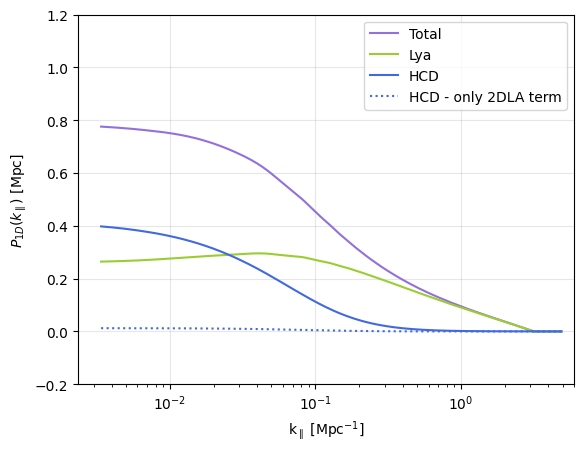

In [13]:
plt.plot(k_w1w2, p1d_tot, color='mediumpurple', label='Total')
#plt.plot(k_w1w2, p1d_total+w1, color='k', linestyle=':', label='Total')
plt.plot(k_w1w2, p1d_lya, color='yellowgreen', label='Lya')
plt.plot(k_w1w2, p1d_hcd, color='royalblue', label='HCD')
plt.plot(k_w1w2, p1d_hcd-w1, color='royalblue', linestyle=':', label='HCD - only 2DLA term')
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
#plt.xlim(0.02, 6)  # This limit is to compare with ASTRID simulation box
plt.ylim(-0.2, 1.2)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]');